In [1]:
import pandas as pd
import numpy as np

import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

from tabulate import tabulate
from SQUIC_functions import *

In [2]:
# chunk_acc = pd.read_csv(f'accounts.csv', chunksize=1000)
# chunk_trns = pd.read_csv(f'transactions.csv', chunksize=1000)

# accounts = pd.concat(chunk_acc)
# transactions = pd.concat(chunk_trns)

accounts = pd.read_csv('accounts.csv')
transactions = pd.read_csv('transactions.csv')

In [3]:
balances = {
    acc_id: [{"date": 0, "balance": round(float(init_bal), 2)}]
    for acc_id, init_bal in zip(accounts["ACCOUNT_ID"], accounts["INIT_BALANCE"])
}

In [4]:
import pandas as pd
from scipy.sparse import lil_matrix

transactions.sort_values(by="TX_ID", inplace=True)

max_account_id = max(transactions["SENDER_ACCOUNT_ID"].max(),
                     transactions["RECEIVER_ACCOUNT_ID"].max()) + 1

matrix = lil_matrix((max_account_id, max_account_id), dtype=int)


for row in transactions.itertuples(index=False):
    orig_acct = row.SENDER_ACCOUNT_ID
    bene_acct = row.RECEIVER_ACCOUNT_ID
    amount = float(row.TX_AMOUNT)  # make sure this is float for balance operations
    tx_type = row.TX_TYPE
    date = row.TIMESTAMP

    # Update sparse matrix
    matrix[orig_acct, bene_acct] += int(amount)

    # Process sender
    if tx_type in ['TRANSFER', 'WITHDRAWAL'] and orig_acct in balances:
        last_balance = balances[orig_acct][-1]["balance"]
        new_balance = last_balance - amount
        balances[orig_acct].append({
            "date": date,
            "balance": round(new_balance, 2)
        })

    # Process receiver
    if tx_type in ['TRANSFER', 'DEPOSIT'] and bene_acct in balances:
        last_balance = balances[bene_acct][-1]["balance"]
        new_balance = last_balance + amount
        balances[bene_acct].append({
            "date": date,
            "balance": round(new_balance, 2)
        })


In [5]:
for i, (acct_id, account_data) in enumerate(balances.items()):
    if i < 1:
        print(acct_id)
        print(account_data)
        break

0
[{'date': 0, 'balance': 184.44}, {'date': 1, 'balance': 0.0}, {'date': 8, 'balance': 5.47}, {'date': 9, 'balance': 10.94}, {'date': 10, 'balance': 16.41}, {'date': 17, 'balance': 21.88}, {'date': 20, 'balance': 27.35}, {'date': 27, 'balance': 32.82}, {'date': 28, 'balance': 38.29}, {'date': 30, 'balance': -146.15}, {'date': 37, 'balance': -330.59}, {'date': 39, 'balance': -325.12}, {'date': 47, 'balance': -509.56}, {'date': 48, 'balance': -504.09}, {'date': 49, 'balance': -688.53}, {'date': 58, 'balance': -683.06}, {'date': 59, 'balance': -677.59}, {'date': 59, 'balance': -862.03}, {'date': 61, 'balance': -856.56}, {'date': 71, 'balance': -1041.0}, {'date': 71, 'balance': -1035.53}, {'date': 77, 'balance': -1219.97}, {'date': 80, 'balance': -1404.41}, {'date': 90, 'balance': -1588.85}, {'date': 99, 'balance': -1583.38}, {'date': 100, 'balance': -1767.82}, {'date': 101, 'balance': -1952.26}, {'date': 111, 'balance': -2136.7}, {'date': 119, 'balance': -2131.23}, {'date': 129, 'balance'

In [6]:
import pandas as pd

# Step 1: Flatten the balances dict to a DataFrame
records = []

for user_id, history in balances.items():
    for entry in history:
        records.append({
            "ACCOUNT_ID": user_id,
            "TIMESTAMP": entry["date"],
            "BALANCE": entry["balance"]
        })

df_balances = pd.DataFrame(records)

# Step 2: Sort by timestamp and user, then remove duplicates keeping the latest
df_balances.sort_values(by=["ACCOUNT_ID", "TIMESTAMP"], inplace=True)
df_balances.drop_duplicates(subset=["ACCOUNT_ID", "TIMESTAMP"], keep="last", inplace=True)

# Step 3: Create a full grid of all timestamps and all users
all_dates = sorted(transactions["TIMESTAMP"].unique())
all_users = df_balances["ACCOUNT_ID"].unique()
grid = pd.MultiIndex.from_product([all_users, all_dates], names=["ACCOUNT_ID", "TIMESTAMP"])

# Step 4: Reindex the balance DataFrame to the full grid
df_balances = df_balances.set_index(["ACCOUNT_ID", "TIMESTAMP"])
df_balances = df_balances.reindex(grid)

# Step 5: Forward fill missing balances (per user)
df_balances["BALANCE"] = df_balances["BALANCE"].groupby(level=0).ffill()

# Step 6: Reset index and pivot to get final table: one row per date, one column per user
df = df_balances.reset_index().pivot(index="TIMESTAMP", columns="ACCOUNT_ID", values="BALANCE")
df.index.name = "date"
df.columns = df.columns.astype(str)  # match your original str(user) keys

In [7]:
df

ACCOUNT_ID,0,1,2,3,4,5,6,7,8,9,...,99990,99991,99992,99993,99994,99995,99996,99997,99998,99999
date,,,,,,,,,,,,,,,,,,,,,
0,184.44,175.80,142.06,125.89,170.50,0.01,178.38,130.33,147.66,158.34,...,939.50,334.41,225.91,481.11,239.82,689.92,-322.57,843.84,1878.99,1598.22
1,0.00,175.80,142.06,125.89,170.50,0.01,357.51,130.33,337.32,158.34,...,477.21,359.90,495.97,1053.55,-369.96,987.37,-34.83,1590.63,3060.62,2466.84
2,0.00,175.80,142.06,125.89,170.50,0.01,357.51,130.33,337.32,158.34,...,674.40,578.87,625.99,1070.93,55.72,180.32,-26.13,2345.89,4130.72,3775.23
3,0.00,175.80,0.01,125.89,170.50,0.01,357.51,130.33,337.32,158.34,...,689.46,64.49,818.31,1362.86,78.44,703.29,94.92,1721.93,4776.94,4756.14
4,0.00,175.80,0.01,125.89,170.50,0.01,357.51,130.33,337.32,158.34,...,34.18,69.32,989.05,1529.32,281.63,814.24,220.43,982.61,5651.38,5629.63
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,-3384.02,2466962.82,-325.77,63.49,-2483.87,57083.82,327400.74,2537.69,987.66,-2374.78,...,6673018.85,9744653.57,7779039.23,24521786.29,9969855.89,13745902.66,9343900.38,13361926.38,32432487.76,23526136.97
196,-3384.02,2466962.82,-325.77,63.49,-2483.87,57083.82,327222.36,2537.69,987.66,-2374.78,...,6673143.12,9744317.14,7779236.62,24521786.29,9970047.56,13745925.44,9344098.33,13362516.54,32432501.50,23526868.66
197,-3384.02,2466962.82,-325.77,63.49,-2634.99,57083.82,327222.36,2537.69,987.66,-2374.78,...,6673147.46,9744451.67,7779241.92,24521786.29,9970064.67,13746132.33,9344256.86,14726820.04,32433513.12,23527281.74


In [8]:
Y = df.T.to_numpy()

In [9]:
# Compute std dev per row
row_std = np.std(Y, axis=1, keepdims=True)

# Avoid division by zero
row_std[row_std == 0] = 1.0

# Normalize each row
Y_new = Y / row_std

In [10]:
print("NaNs?", np.isnan(Y_new).any())
print("Infs?", np.isinf(Y_new).any())
print("Max:", np.max(Y_new))
print("Min:", np.min(Y_new))
print("Mean std per row (should be 1):", round(np.mean(np.std(Y_new, axis=1)), 2))

NaNs? False
Infs? False
Max: 19.75861940729792
Min: -14.196414655011077
Mean std per row (should be 1): 1.0


In [11]:
l = [0.99999999, 0.9999995, 0.999999]

In [12]:
squic_norm_dict = {}

In [13]:
ROWS = Y_new.shape[0]
ROWS

100000

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100000 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e+00 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=5.18e+00 nnz(S)/p=1.10e+00
* iter=1 time=1.49e-01 obj=1.69e+05 |delta(obj)|/obj=4.09e-01 nnz(X,L,W)/p=[1.10e+00 5.53e-01 1.00e+00] lns_iter=2 
* iter=2 time=2.33e-01 obj=1.69e+05 |delta(obj)|/obj=0.00e+00 nnz(X,L,W)/p=[1.10e+00 5.53e-01 1.00e+00] lns_iter=1 
#SQUIC Finished: time=5.58e+00 nnz(X,W)/p=[1.10e

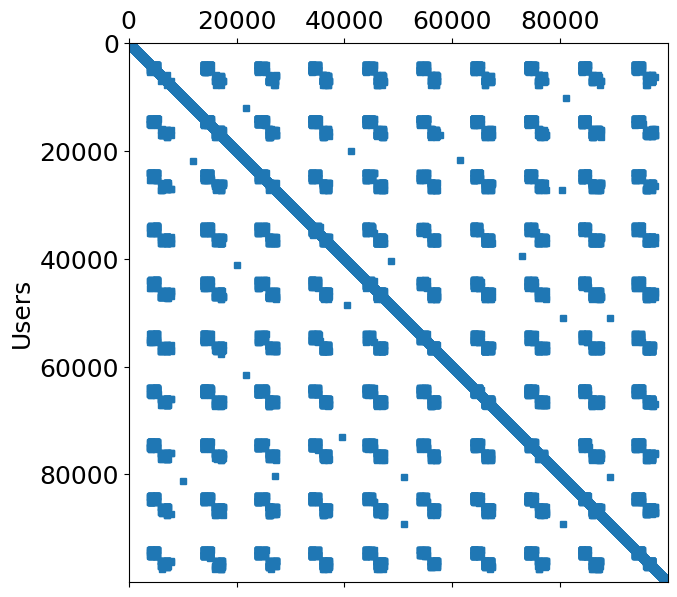

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100000 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.999995e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=5.19e+00 nnz(S)/p=1.60e+00
* iter=1 time=1.52e-01 obj=1.69e+05 |delta(obj)|/obj=4.09e-01 nnz(X,L,W)/p=[1.60e+00 8.78e-01 1.00e+00] lns_iter=2 
* iter=2 time=2.31e-01 obj=1.69e+05 |delta(obj)|/obj=1.14e-12 nnz(X,L,W)/p=[1.60e+00 8.78e-01 1.00e+00] lns_iter=1 
#SQUIC Finished: time=5.59e+00 nnz(X,W)/p=[1.60e

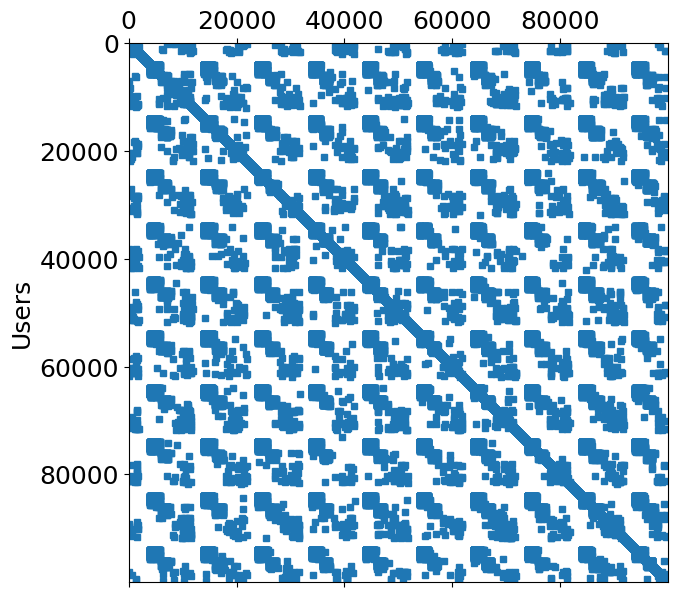

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100000 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.999990e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=5.19e+00 nnz(S)/p=2.08e+00
* iter=1 time=1.60e-01 obj=1.69e+05 |delta(obj)|/obj=4.09e-01 nnz(X,L,W)/p=[2.08e+00 1.39e+00 1.00e+00] lns_iter=2 
* iter=2 time=2.25e-01 obj=1.69e+05 |delta(obj)|/obj=0.00e+00 nnz(X,L,W)/p=[2.08e+00 1.39e+00 1.00e+00] lns_iter=1 
#SQUIC Finished: time=5.59e+00 nnz(X,W)/p=[2.08e

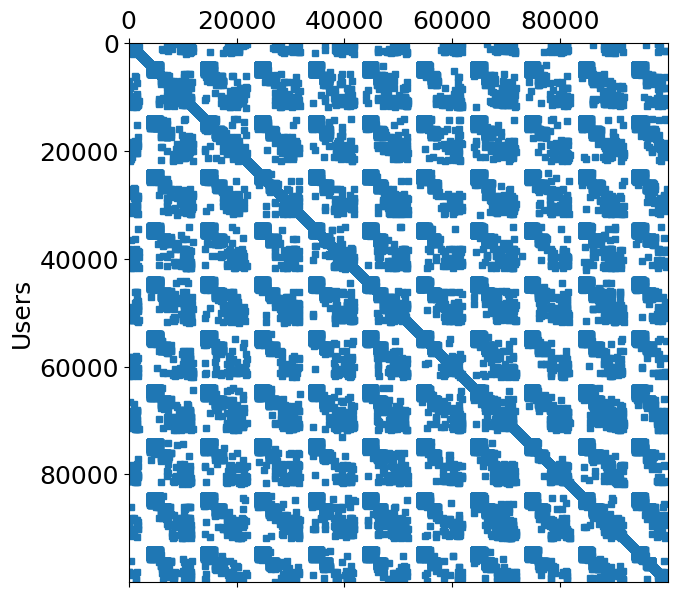

In [14]:
data_nnz = []
data_nnzr = []
data_time = []
data_sym = []

for rho in l:
    X, _, computation_time = compute_squic(Y_new, rho)
    computation_time = round(computation_time, 2)
    squic_norm_dict[rho] = X
    print(f"time required: {computation_time} seconds")

    nonz, nonz_r = nnz_fit(squic_norm_dict[rho], ROWS)

    print("Checking if symmetric")
    if check_symmetric_sparse(squic_norm_dict[rho]):
        print(f"✅ Matrix is symmetric per rho {rho}")
        data_sym.append('Yes')
    else:
        print(f"❌ Matrix is not symmetric per rho {rho}")
        data_sym.append('No')

    data_nnz.append(nonz)
    data_nnzr.append(nonz_r)
    data_time.append(computation_time)

    if nonz == ROWS:
        print(f"For rho = {rho} just element on the diagonal")
        sparsity_pattern(squic_norm_dict[rho])
    elif nonz == ROWS * ROWS:
        print(f"For rho = {rho} big dense matrix")
        print(f"nnz = {nonz}")
        print(f"nnz/row = {nonz_r}")
        sparsity_pattern(squic_norm_dict[rho])
    else:
        print(f"For rho = {rho} there are some nnz")
        print(f"nnz = {nonz}")
        print(f"nnz/row = {nonz_r}")
        sparsity_pattern(squic_norm_dict[rho])


table_squic_norm = [
    ["NNZ"] + data_nnz,
    ["NNZ/Row"] + data_nnzr,
    ["Time (s)"] + data_time,
    ["Symmetric"] + data_sym
]

# SQUIC-Fit


----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    1.229394e+01
 Y:         100000 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e+00 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* compute sample covariance matrix S: nnz(S)/p=1.10e+00 time=6.20e+00
* iter=1 time=1.39e-01 obj=2.83e+06 |delta(obj)|/obj=9.65e-01 nnz(X,L,W)/p=[1.10e+00 5.53e-01 1.00e+00] lns_iter=2 
* iter=2 time=2.27e-01 obj=1.50e+06 |delta(obj)|/obj=8.87e-01 nnz(X,L,W)/p=[1.10e+00 5.53e-01 1.00e+00] lns_iter=2 
* iter=3 time=3.30e-01 obj=8.34e+05 

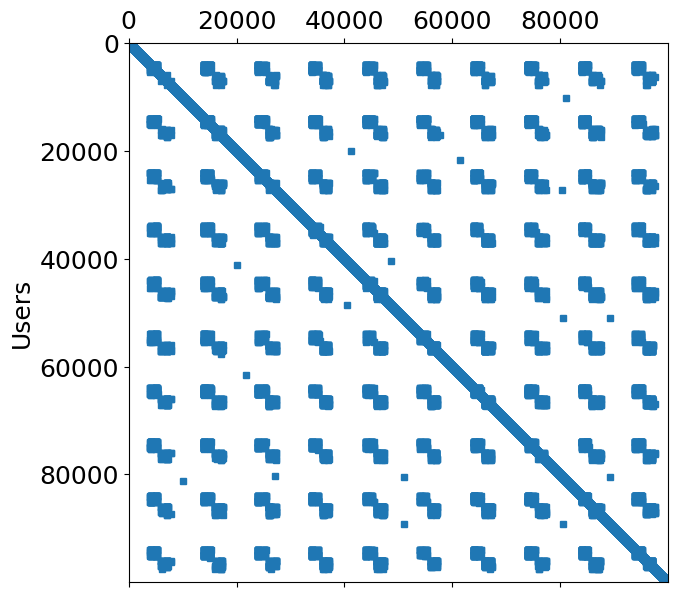

✅ Matrix is symmetric per rho 0.99999999

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    1.229394e+01
 Y:         100000 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.999995e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* compute sample covariance matrix S: nnz(S)/p=1.60e+00 time=5.92e+00
* iter=1 time=1.49e-01 obj=2.83e+06 |delta(obj)|/obj=9.65e-01 nnz(X,L,W)/p=[1.60e+00 8.78e-01 1.00e+00] lns_iter=2 
* iter=2 time=2.47e-01 obj=1.50e+06 |delta(obj)|/obj=8.87e-01 nnz(X,L,W)/p=[1.60e+00 8.78e-01 1.00e+00] lns_ite

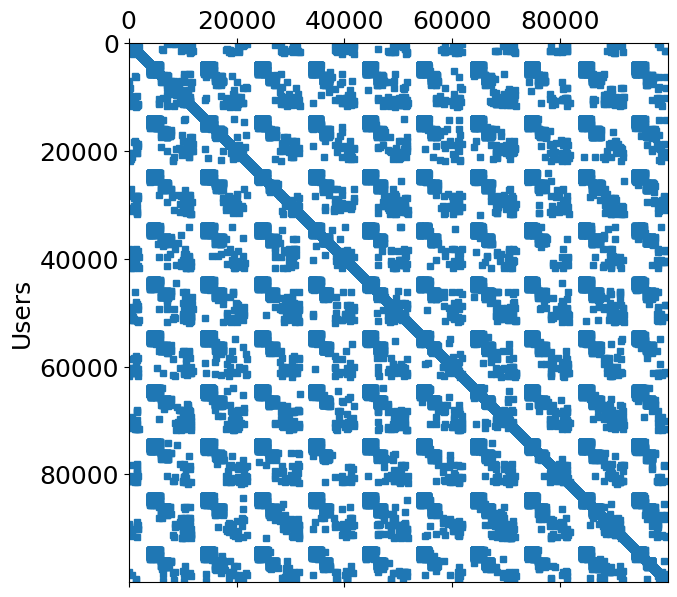

✅ Matrix is symmetric per rho 0.9999995

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    1.229394e+01
 Y:         100000 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.999990e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* compute sample covariance matrix S: nnz(S)/p=2.08e+00 time=6.09e+00
* iter=1 time=1.61e-01 obj=2.83e+06 |delta(obj)|/obj=9.65e-01 nnz(X,L,W)/p=[2.08e+00 1.39e+00 1.00e+00] lns_iter=2 
* iter=2 time=2.59e-01 obj=1.50e+06 |delta(obj)|/obj=8.87e-01 nnz(X,L,W)/p=[2.08e+00 1.39e+00 1.00e+00] lns_iter

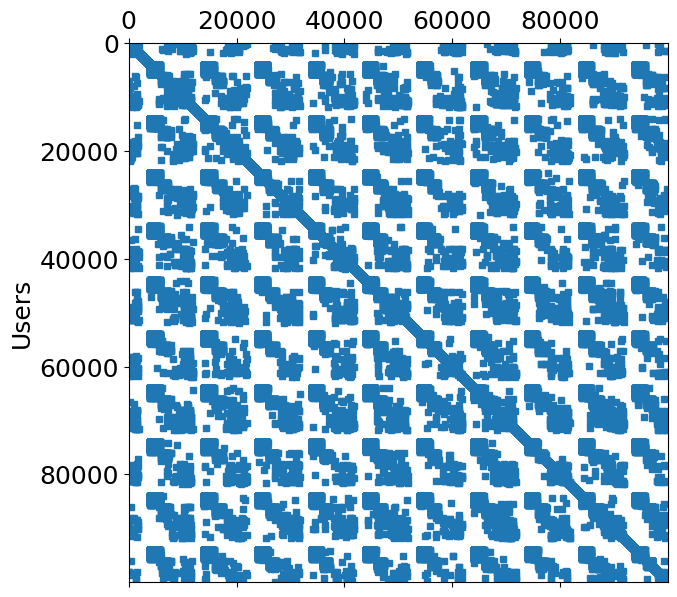

✅ Matrix is symmetric per rho 0.999999


In [15]:
fit_norm_dict = {}

l = [0.99999999, 0.9999995, 0.999999]

data_nnz = []
data_nnzr = []
data_time = []
data_sym = []

for rho in l:
    fit_norm_dict[rho], end_time = squic_fit_matrix_sparse(Y_new, l=rho, matrix=matrix)
    end_time = round(end_time, 2)
    print(f"required time: {end_time}")

    nnz, nnz_r = nnz_fit(fit_norm_dict[rho], ROWS)
    print(f"nnz = {nnz} per rows = {nnz_r}")

    sparsity_pattern(fit_norm_dict[rho])

    if check_symmetric_sparse(fit_norm_dict[rho]):
        print(f"✅ Matrix is symmetric per rho {rho}")
        data_sym.append("Yes")
    else:
        print(f"❌ Matrix is not symmetric per rho {rho}")
        data_sym.append("No")

    data_nnz.append(nnz)
    data_nnzr.append(nnz_r)
    data_time.append(end_time)

table_fit_norm = [
    ["NNZ"] + data_nnz,
    ["NNZ/Row"] + data_nnzr,
    ["Time (s)"] + data_time,
    ["Symmetric"] + data_sym
]


In [16]:
from tabulate import tabulate

In [17]:
def table(data, title, l):
    table = tabulate(
        data,
        headers=[title] + l,
        tablefmt="fancy_grid",
        numalign="center",
        stralign="center"
    )
    return table

In [18]:
print(table(table_squic_norm, "SQUIC NORM", l))

print(table(table_fit_norm, "SQUIC FIT NORM", l))

╒══════════════╤══════════════╤═════════════╤════════════╕
│  SQUIC NORM  │  0.99999999  │  0.9999995  │  0.999999  │
╞══════════════╪══════════════╪═════════════╪════════════╡
│     NNZ      │    110326    │   159520    │   207956   │
├──────────────┼──────────────┼─────────────┼────────────┤
│   NNZ/Row    │     1.1      │     1.6     │    2.08    │
├──────────────┼──────────────┼─────────────┼────────────┤
│   Time (s)   │     5.58     │    5.59     │    5.59    │
├──────────────┼──────────────┼─────────────┼────────────┤
│  Symmetric   │     Yes      │     Yes     │    Yes     │
╘══════════════╧══════════════╧═════════════╧════════════╛
╒══════════════════╤══════════════╤═════════════╤════════════╕
│  SQUIC FIT NORM  │  0.99999999  │  0.9999995  │  0.999999  │
╞══════════════════╪══════════════╪═════════════╪════════════╡
│       NNZ        │    110322    │   159482    │   207638   │
├──────────────────┼──────────────┼─────────────┼────────────┤
│     NNZ/Row      │     1.1      │ 